# 03 · Feature Engineering — Technical Indicators and Lags
**Data Science Diploma · ENES UNAM León**

We build the **input variables (features)** for our models. All features are **scale-invariant** (returns, ratios, percentages) so models generalize across different price levels.

### Features to create:
| Category | Feature | Description |
|---|---|---|
| **Return lags** | return_lag_1..14 | Daily % return from N days ago |
| **Trend** | Close_to_SMA7, Close_to_SMA21 | % distance from simple moving average |
| **Trend** | Close_to_EMA12, Close_to_EMA26 | % distance from exponential moving average |
| **Momentum** | RSI_14 | Relative Strength Index (already 0–100) |
| **Momentum** | MACD_pct, MACD_signal_pct | MACD normalized by closing price (%) |
| **Volatility** | BB_width, BB_position | Bollinger band width and price position within bands |
| **Volatility** | volatility_21d | Rolling std dev of daily returns |
| **Volume** | Volume_change, Volume_ratio | % change and ratio to 7-day SMA |
| **Calendar** | day_of_week, month | |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Base paths
RAW_DIR       = os.path.join(os.getcwd(), 'data', 'raw')
PROCESSED_DIR = os.path.join(os.getcwd(), 'data', 'processed')
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROCESSED_DIR, 'sol_usd_eda.csv'), index_col=0, parse_dates=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Data loaded: {df.shape}')
df.head(3)

Data loaded: (444, 7)


,Close,High,Low,Open,Volume,daily_return,volatility_21d
Date,,,,,,,
2025-01-01,193.873734,194.818497,187.879456,189.266922,2324231668,NaN,NaN
2025-01-02,207.767044,209.066727,193.258530,193.872131,4230329837,7.166164,NaN
2025-01-03,217.747330,219.559525,205.652405,207.767609,4064420852,4.803594,NaN


## 3.1 Return-Based Price Lags

Instead of absolute prices (which shift across market cycles), we use **daily % returns shifted N days back**. This makes the features scale-invariant — a +2% move means the same at any price level.

In [ ]:
# Return lags: daily % return from N days ago (scale-invariant)
daily_returns = df['Close'].pct_change() * 100

for lag in [1, 2, 3, 5, 7, 14]:
    df[f'return_lag_{lag}'] = daily_returns.shift(lag)

print('Return lags created')
df[['Close'] + [f'return_lag_{lag}' for lag in [1, 2, 3, 5, 7]]].tail(5)

Return lags created ✓


,Close,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_7
Date,,,,,,
2026-03-16,96.223724,4.747479,-0.093704,1.479835,0.846601,4.057092
2026-03-17,94.705971,4.305499,4.747479,-0.093704,0.349860,1.062037
2026-03-18,90.065720,-1.577317,4.305499,4.747479,1.479835,0.846601
2026-03-19,88.917847,-4.899640,-1.577317,4.305499,-0.093704,0.349860
2026-03-20,89.853569,-1.274484,-4.899640,-1.577317,4.747479,1.479835


## 3.2 Moving Averages — Price-Relative Ratios

Instead of absolute SMA/EMA values, we compute **how far the current price is from each MA** (in %). A value of +3% means the price is 3% above the moving average, regardless of the absolute price level.

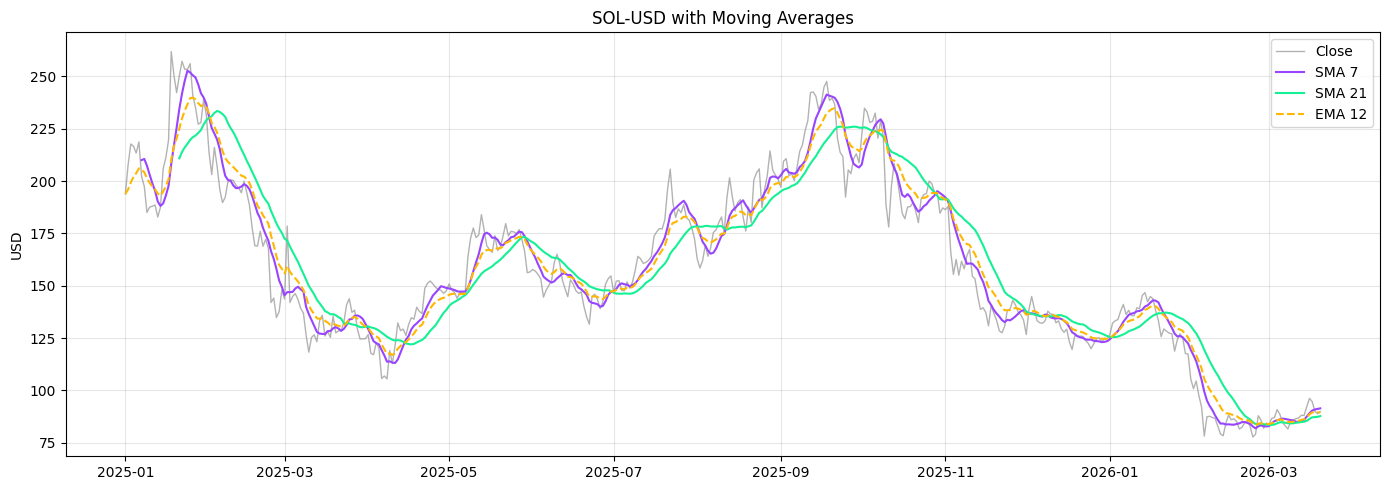

In [3]:
# SMA and EMA (kept for plotting and MACD calculation)
df['SMA_7']  = df['Close'].rolling(window=7).mean()
df['SMA_21'] = df['Close'].rolling(window=21).mean()
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# Price relative to moving averages (scale-invariant, in %)
df['Close_to_SMA7']  = (df['Close'] / df['SMA_7']  - 1) * 100
df['Close_to_SMA21'] = (df['Close'] / df['SMA_21'] - 1) * 100
df['Close_to_EMA12'] = (df['Close'] / df['EMA_12'] - 1) * 100
df['Close_to_EMA26'] = (df['Close'] / df['EMA_26'] - 1) * 100

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], label='Close', color='gray', alpha=0.6, linewidth=1)
plt.plot(df.index, df['SMA_7'],  label='SMA 7',  color='#9945FF', linewidth=1.5)
plt.plot(df.index, df['SMA_21'], label='SMA 21', color='#14F195', linewidth=1.5)
plt.plot(df.index, df['EMA_12'], label='EMA 12', color='#FFB800', linewidth=1.5, linestyle='--')
plt.title('SOL-USD with Moving Averages')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '03_moving_averages.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.3 RSI — Relative Strength Index

Measures the speed and magnitude of price changes. Range 0–100:
- **> 70** → overbought (possible correction)
- **< 30** → oversold (possible bounce)

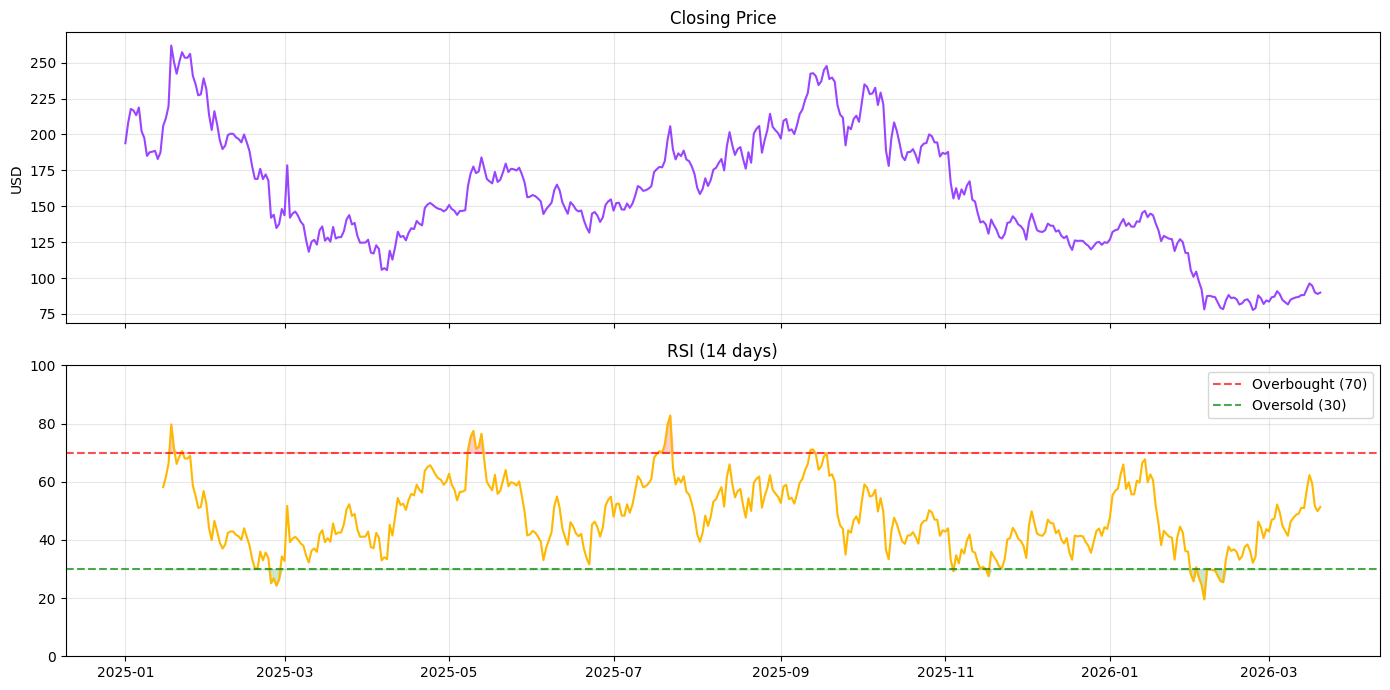

In [4]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'], 14)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df.index, df['Close'], color='#9945FF', linewidth=1.5)
axes[0].set_title('Closing Price')
axes[0].set_ylabel('USD')

axes[1].plot(df.index, df['RSI_14'], color='#FFB800', linewidth=1.5)
axes[1].axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(df.index, 70, df['RSI_14'].clip(lower=70), alpha=0.2, color='red')
axes[1].fill_between(df.index, df['RSI_14'].clip(upper=30), 30, alpha=0.2, color='green')
axes[1].set_title('RSI (14 days)')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '03_rsi.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.4 MACD

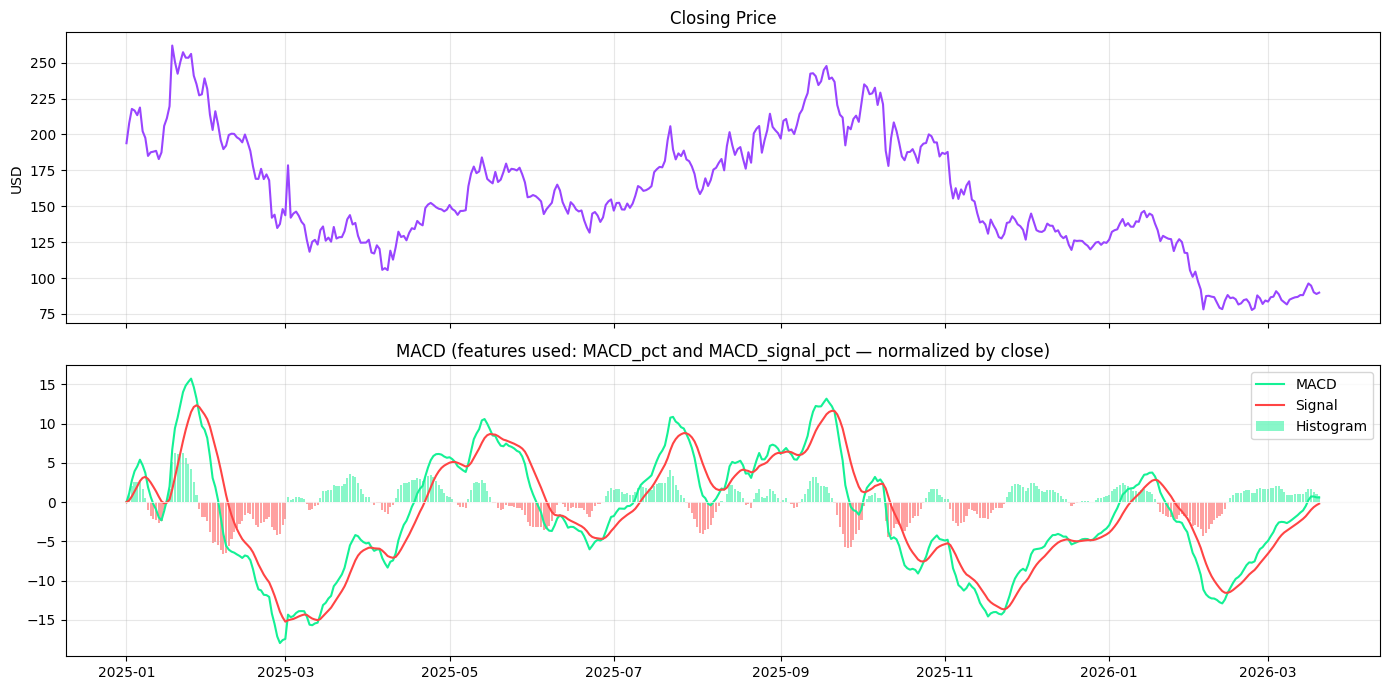

In [5]:
# MACD = EMA_12 - EMA_26
df['MACD']        = df['EMA_12'] - df['EMA_26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# Normalize by close price (scale-invariant, in %)
df['MACD_pct']        = df['MACD']        / df['Close'] * 100
df['MACD_signal_pct'] = df['MACD_signal'] / df['Close'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df.index, df['Close'], color='#9945FF', linewidth=1.5)
axes[0].set_title('Closing Price')
axes[0].set_ylabel('USD')

axes[1].plot(df.index, df['MACD'], label='MACD', color='#14F195', linewidth=1.5)
axes[1].plot(df.index, df['MACD_signal'], label='Signal', color='#FF4444', linewidth=1.5)
colors_macd = ['#14F195' if v >= 0 else '#FF4444' for v in df['MACD_hist'].fillna(0)]
axes[1].bar(df.index, df['MACD_hist'], color=colors_macd, alpha=0.5, label='Histogram')
axes[1].axhline(0, color='white', linewidth=0.5)
axes[1].set_title('MACD (features used: MACD_pct and MACD_signal_pct — normalized by close)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '03_macd.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Bollinger Bands

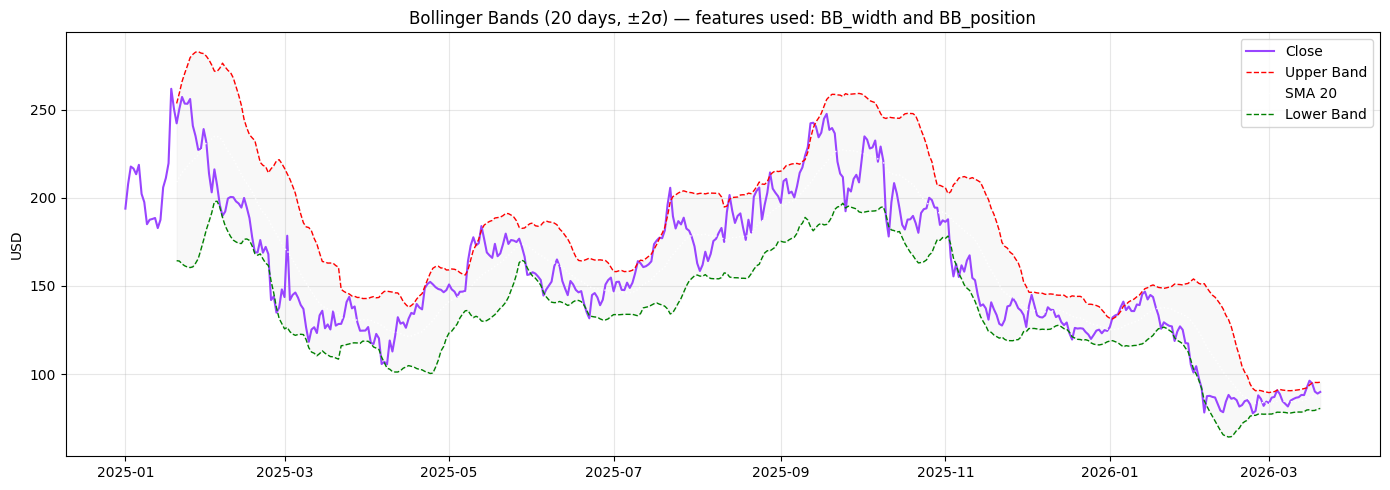

In [6]:
window_bb = 20
df['BB_mid']   = df['Close'].rolling(window_bb).mean()
df['BB_std']   = df['Close'].rolling(window_bb).std()
df['BB_upper'] = df['BB_mid'] + 2 * df['BB_std']
df['BB_lower'] = df['BB_mid'] - 2 * df['BB_std']
df['BB_width']    = (df['BB_upper'] - df['BB_lower']) / df['BB_mid']          # relative band width
df['BB_position'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])  # 0=lower, 1=upper

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], label='Close', color='#9945FF', linewidth=1.5)
plt.plot(df.index, df['BB_upper'], label='Upper Band', color='red', linewidth=1, linestyle='--')
plt.plot(df.index, df['BB_mid'], label='SMA 20', color='white', linewidth=1, linestyle=':')
plt.plot(df.index, df['BB_lower'], label='Lower Band', color='green', linewidth=1, linestyle='--')
plt.fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.05, color='gray')
plt.title('Bollinger Bands (20 days, ±2σ) — features used: BB_width and BB_position')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '03_bollinger.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Volume and Calendar Features

In [ ]:
# Volume features (scale-invariant)
df['Volume_change'] = df['Volume'].pct_change() * 100
df['Volume_SMA7']   = df['Volume'].rolling(7).mean()
df['Volume_ratio']  = df['Volume'] / df['Volume_SMA7']  # relative volume vs recent average

# Calendar features
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['month']       = df.index.month

print('Additional features created')

Additional features created ✓


## 3.7 Target Variable: Next Day's Return

The target is the **next-day % return** (not absolute price). This is stationary and scale-invariant — the model learns to predict whether price will go up or down by how much, regardless of current price level. Price is reconstructed in notebook 04.

In [8]:
# Target: next-day return (%) — stationary and scale-invariant
# shift(-1) gives tomorrow's return; price is reconstructed in notebook 04
df['Target'] = df['Close'].pct_change().shift(-1) * 100

print('Target variable (next-day return %) created')
df[['Close', 'Target']].tail(5)

Target variable (next-day return %) created ✓


,Close,Target
Date,,
2026-03-16,96.223724,-1.577317
2026-03-17,94.705971,-4.899640
2026-03-18,90.065720,-1.274484
2026-03-19,88.917847,1.052345
2026-03-20,89.853569,NaN


## 3.8 Final Cleanup — Remove NaN from Rolling Windows

In [9]:
print(f'Rows before cleaning : {len(df)}')
print(f'NaN per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

df.dropna(inplace=True)

print(f'\nRows after cleaning : {len(df)}')
print('All columns have no NaN')

Rows before cleaning : 444
NaN per column:
daily_return       1
volatility_21d    21
return_lag_1       2
return_lag_2       3
return_lag_3       4
return_lag_5       6
return_lag_7       8
return_lag_14     15
SMA_7              6
SMA_21            20
Close_to_SMA7      6
Close_to_SMA21    20
RSI_14            14
BB_mid            19
BB_std            19
BB_upper          19
BB_lower          19
BB_width          19
BB_position       19
Volume_change      1
Volume_SMA7        6
Volume_ratio       6
Target             1
dtype: int64

Rows after cleaning : 422
All columns have no NaN


## 3.9 Feature Summary and Correlation with Target

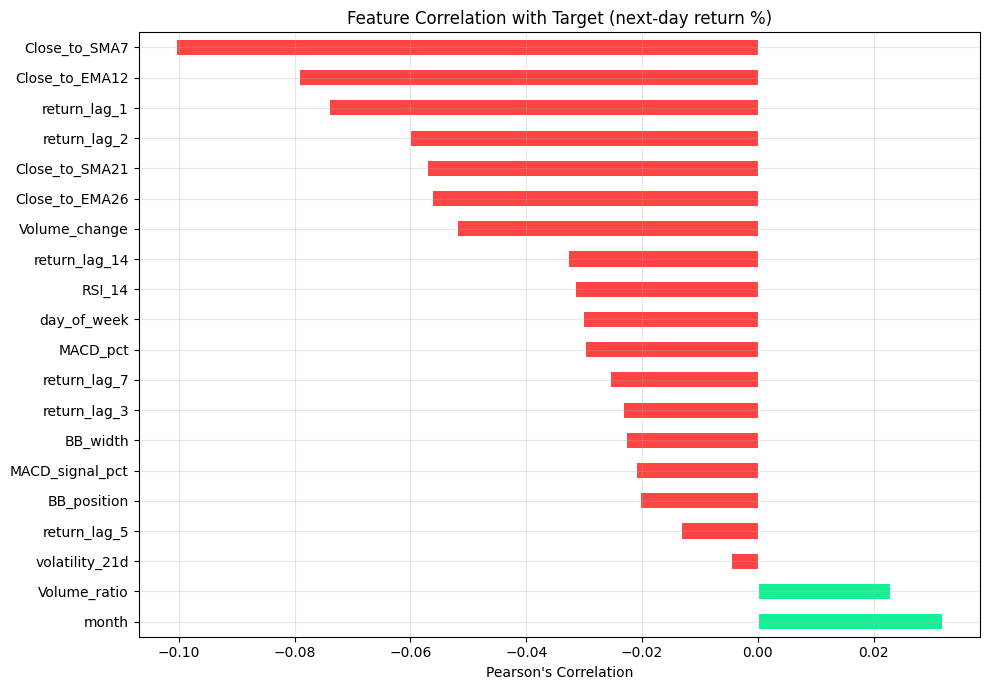

month              0.031769
Volume_ratio       0.022819
volatility_21d    -0.004382
return_lag_5      -0.013024
BB_position       -0.020170
MACD_signal_pct   -0.020790
BB_width          -0.022645
return_lag_3      -0.023096
return_lag_7      -0.025289
MACD_pct          -0.029595
day_of_week       -0.030036
RSI_14            -0.031357
return_lag_14     -0.032588
Volume_change     -0.051835
Close_to_EMA26    -0.056074
Close_to_SMA21    -0.056925
return_lag_2      -0.059905
return_lag_1      -0.073879
Close_to_EMA12    -0.078995
Close_to_SMA7     -0.100327
Name: Target, dtype: float64


In [10]:
feature_cols = [
    # Return-based price lags (scale-invariant)
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_7', 'return_lag_14',
    # Price vs moving averages (%)
    'Close_to_SMA7', 'Close_to_SMA21', 'Close_to_EMA12', 'Close_to_EMA26',
    # Momentum
    'RSI_14', 'MACD_pct', 'MACD_signal_pct',
    # Volatility
    'BB_width', 'BB_position', 'volatility_21d',
    # Volume
    'Volume_change', 'Volume_ratio',
    # Calendar
    'day_of_week', 'month'
]

corr_target = df[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#14F195' if v > 0 else '#FF4444' for v in corr_target]
corr_target.plot(kind='barh', color=colors, edgecolor='none')
plt.axvline(0, color='white', linewidth=0.8)
plt.title('Feature Correlation with Target (next-day return %)')
plt.xlabel("Pearson's Correlation")
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '03_target_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(corr_target)

## 3.10 Save Final Dataset

In [11]:
df.to_csv(os.path.join(PROCESSED_DIR, 'sol_usd_features.csv'))
print(f'Dataset with features saved')
print(f'Final shape : {df.shape}')
print(f'Features    : {len(feature_cols)}')
print(f'Period      : {df.index.min().date()} → {df.index.max().date()}')

Dataset with features saved
Final shape : (422, 39)
Features    : 20
Period      : 2025-01-22 → 2026-03-19


---
## ✅ Features Created

All features are **scale-invariant** (%, ratios) so models generalize across different price levels.

```python
FEATURE_COLS = [
    # Return-based price lags
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_7', 'return_lag_14',
    # Price vs moving averages (%)
    'Close_to_SMA7', 'Close_to_SMA21', 'Close_to_EMA12', 'Close_to_EMA26',
    # Momentum
    'RSI_14', 'MACD_pct', 'MACD_signal_pct',
    # Volatility
    'BB_width', 'BB_position', 'volatility_21d',
    # Volume
    'Volume_change', 'Volume_ratio',
    # Calendar
    'day_of_week', 'month'
]
TARGET = 'Target'  # next-day return (%)
# Price reconstruction: pred_price = Close * (1 + Target/100)
```

**Next step →** `04_modeling.ipynb`